In [1]:
# import necessary packages
import openeo

# connect with the backend
eoconn = openeo.connect(
       "openeo.terrascope.be"
        ).authenticate_oidc()

Authenticated using refresh token.


In [2]:
# Setup process parameters
aoi = {
        "type": "Polygon",
        "coordinates": [
          [
            [
              5.179324150085449,
              51.2498689148547
            ],
            [
              5.178744792938232,
              51.24672597710759
            ],
            [
              5.185289382934569,
              51.24504696935156
            ],
            [
              5.18676996231079,
              51.245342479161295
            ],
            [
              5.187370777130127,
              51.24918393390799
            ],
            [
              5.179324150085449,
              51.2498689148547
            ]
          ]
        ]
      }
date = "2024-01-01", "2024-12-31"
biopar = "FAPAR"

# Create a processing graph from the CropSAR process using an active openEO connection
cropsar = eoconn.datacube_from_process(
          "cropsar1d", 
          namespace="https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/3091373f923c6a301ee73ae49bd16a132b8a1b2c/algorithm_catalog/vito/cropsar1d/openeo_udp/cropsar1d.json",
          geometry=aoi,
          startdate = date[0],
          enddate = date[1],
          output=biopar
          )

In [3]:
job = cropsar.create_job(
                title="Cropsar1D job example"
                )
job.start_and_wait()

0:00:00 Job 'j-260628125236450ab001caa4c68ad42f': send 'start'
0:00:15 Job 'j-260628125236450ab001caa4c68ad42f': queued (progress 0%)
0:00:20 Job 'j-260628125236450ab001caa4c68ad42f': queued (progress 0%)
0:00:29 Job 'j-260628125236450ab001caa4c68ad42f': queued (progress 0%)
0:00:37 Job 'j-260628125236450ab001caa4c68ad42f': queued (progress 0%)
0:00:47 Job 'j-260628125236450ab001caa4c68ad42f': queued (progress 0%)
0:01:04 Job 'j-260628125236450ab001caa4c68ad42f': running (progress 7.8%)
0:01:19 Job 'j-260628125236450ab001caa4c68ad42f': running (progress 10.0%)
0:01:42 Job 'j-260628125236450ab001caa4c68ad42f': running (progress 12.9%)
0:02:06 Job 'j-260628125236450ab001caa4c68ad42f': running (progress 15.8%)
0:02:42 Job 'j-260628125236450ab001caa4c68ad42f': running (progress 19.9%)
0:03:20 Job 'j-260628125236450ab001caa4c68ad42f': running (progress 23.7%)
0:04:11 Job 'j-260628125236450ab001caa4c68ad42f': finished (progress 100%)


<BatchJob job_id='j-260628125236450ab001caa4c68ad42f'>

In [4]:
results = job.get_results()
results.download_files("cropsar1d_output/")

[PosixPath('cropsar1d_output/result.json'),
 PosixPath('cropsar1d_output/job-results.json')]

In [5]:
import pandas as pd
import json 

vitodev_cropsar_py11 = json.load(open("cropsar1d_output/result.json"))

#dictionary to dataframe
dataframe = pd.DataFrame(list(vitodev_cropsar_py11["Field_0_cropSAR"].items()), columns=['Date', 'fapar'])
dataframe['Date'] = pd.to_datetime(dataframe['Date'])

# sort date column
dataframe = dataframe.sort_values(by='Date')

<Figure size 3000x1000 with 0 Axes>

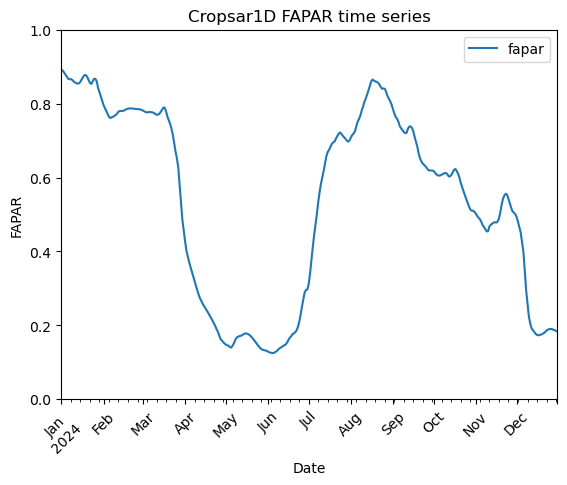

In [6]:
import pandas as pd
import matplotlib.pyplot as plt


plt.figure(figsize=(30, 10))
# plot the date in x and band_0 in y
dataframe.plot(
    x='Date', 
    y='fapar',  
    title='Cropsar1D FAPAR time series', 
    xlabel='Date', 
    ylabel='FAPAR')
# tilt the x label
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()